# Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# Data Exploration

In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
superconductivty_data = fetch_ucirepo(id=464) 
  
# data (as pandas dataframes) 
X_df = superconductivty_data.data.features 
y_df = superconductivty_data.data.targets 
  
# metadata 
print(superconductivty_data.metadata) 
  
# variable information 
print(superconductivty_data.variables) 


{'uci_id': 464, 'name': 'Superconductivty Data', 'repository_url': 'https://archive.ics.uci.edu/dataset/464/superconductivty+data', 'data_url': 'https://archive.ics.uci.edu/static/public/464/data.csv', 'abstract': 'Two file s contain data on 21263 superconductors and their relevant features.', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 21263, 'num_features': 81, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['critical_temp'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C53P47', 'creators': ['Kam Hamidieh'], 'intro_paper': {'ID': 452, 'type': 'NATIVE', 'title': 'A data-driven statistical model for predicting the critical temperature of a superconductor', 'authors': 'K. Hamidieh', 'venue': 'Computational materials science', 'year': 2018, 'journal': None, 'DOI': None, 'URL': 'http

In [ ]:
print("Any missing values in the dataset? ", X_df.isnull().values.any())
print("Any NaN values in the dataset? ", X_df.isna().values.any())
print()
print(X_df.info())

Any missing values in the dataset?  False
Any NaN values in the dataset?  False

<class 'pandas.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 81 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie  

In [ ]:
print("Any missing values in Tc? ", y_df.isnull().values.any())
print("Any NaN values in Tc? ", y_df.isna().values.any())
print()
print(y_df.info())
y_df.describe()

Any missing values in Tc?  False
Any NaN values in Tc?  False

<class 'pandas.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   critical_temp  21263 non-null  float64
dtypes: float64(1)
memory usage: 166.2 KB
None


,critical_temp
count,21263.000000
mean,34.421219
std,34.254362
min,0.000210
25%,5.365000
50%,20.000000
75%,63.000000
max,185.000000


Study the distribution of the target

In [ ]:
y = np.array(y_df).flatten()
y.shape

(21263,)

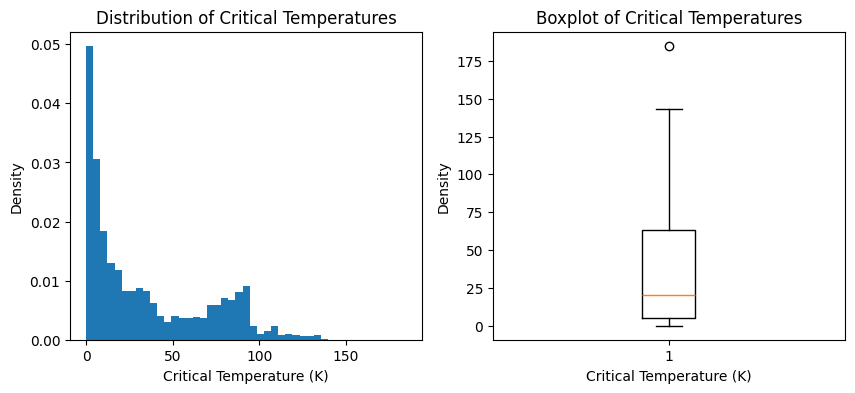

In [ ]:
plt.subplots(1,2, figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y, bins="auto", density=True)
plt.xlabel("Critical Temperature (K)")
plt.ylabel("Density")
plt.title("Distribution of Critical Temperatures")
plt.subplot(1,2,2)
plt.boxplot(y)
plt.xlabel("Critical Temperature (K)")
plt.ylabel("Density")
plt.title("Boxplot of Critical Temperatures")
plt.show()

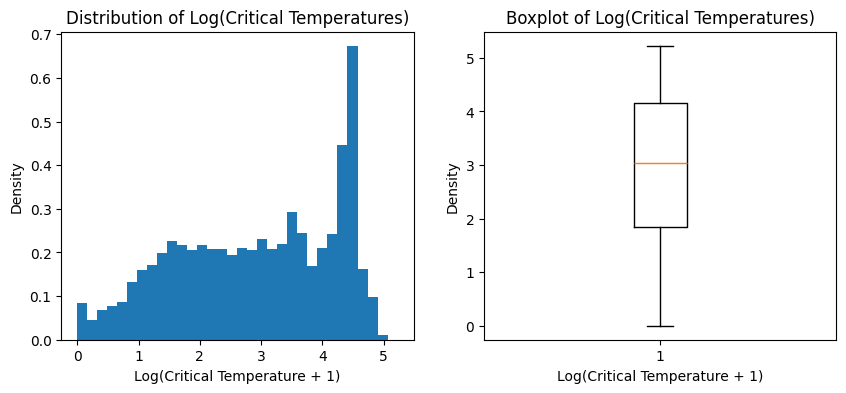

In [ ]:
y_log = np.log1p(y)
plt.subplots(1,2, figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y_log, bins="auto", density=True)
plt.xlabel("Log(Critical Temperature + 1)")
plt.ylabel("Density")
plt.title("Distribution of Log(Critical Temperatures)")
plt.subplot(1,2,2)
plt.boxplot(y_log)
plt.xlabel("Log(Critical Temperature + 1)")
plt.ylabel("Density")
plt.title("Boxplot of Log(Critical Temperatures)")
plt.show()

# First Model Attempt: Linear Regression with All Features

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42)
reg = LinearRegression()
reg.fit(X_train, np.log1p(y_train))
y_pred = np.expm1(reg.predict(X_test))

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 320.15913627788535
R^2 Score: 0.7218620686459114


# Second Model Attempt: Lasso Regression to Select Relevant Features

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train_scaled, np.log1p(y_train))
y_pred_lasso = lasso_reg.predict(X_test_scaled)

print("Mean Squared Error:", mean_squared_error(y_test, np.expm1(y_pred_lasso)))
print("R^2 Score:", r2_score(y_test, np.expm1(y_pred_lasso)))

Mean Squared Error: 515.8361575847146
R^2 Score: 0.5518678509185981


In [ ]:
lasso_cv_reg = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5)
lasso_cv_reg.fit(X_train_scaled, np.log1p(y_train))
y_pred_lasso_cv = np.expm1(lasso_cv_reg.predict(X_test_scaled))
print("Best alpha:", lasso_cv_reg.alpha_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lasso_cv))
print("R^2 Score:", r2_score(y_test, y_pred_lasso_cv))

/opt/anaconda3/envs/tflow/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.739e+00, tolerance: 2.251e+00
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/tflow/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.391e+01, tolerance: 2.251e+00
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/envs/tflow/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing re

Best alpha: 0.0001
Mean Squared Error: 322.1015925029305
R^2 Score: 0.7201745617315032


/opt/anaconda3/envs/tflow/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.656e+03, tolerance: 2.825e+00
  model = cd_fast.enet_coordinate_descent(


# Third Model Attempt: Ridge Regression

In [ ]:
ridge_reg = Ridge(alpha=0.1)
ridge_reg.fit(X_train_scaled, np.log1p(y_train))
y_pred_ridge = np.expm1(ridge_reg.predict(X_test_scaled))

print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))
print("R^2 Score:", r2_score(y_test, y_pred_ridge))

Mean Squared Error: 319.8959325867767
R^2 Score: 0.7220907265908971


In [ ]:
ridge_cv_reg = RidgeCV(alphas=np.logspace(-4, 0, 50), cv=5)
ridge_cv_reg.fit(X_train_scaled, np.log1p(y_train))
y_pred_ridge_cv = np.expm1(ridge_cv_reg.predict(X_test_scaled))
print("Best alpha:", ridge_cv_reg.alpha_)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge_cv))
print("R^2 Score:", r2_score(y_test, y_pred_ridge_cv))

Best alpha: 0.08685113737513521
Mean Squared Error: 319.9261242644557
R^2 Score: 0.7220644976009287
